# Patent and Policy Citation Landscape

This notebook characterizes the external citation pathways of the ML-OPF
academic literature by comparing scholarly publications cited in patents
with those cited in policy documents.

The analysis covers:

1. coverage of patent and policy citations;
2. temporal evolution of the two citation pathways;
3. most frequently patent-cited publications;
4. most frequently policy-cited publications; and
5. leading journals, authors, and countries represented in each pathway.

In [1]:
# ---------------------------------------------------------
# Imports
# ---------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

PROJECT_DIR = (
    Path.cwd()
    .resolve()
    .parent
)


DATA_DIR = (
    PROJECT_DIR
    / "data"
)

LDA_DATA_DIR = (
    DATA_DIR
    / "lda"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "output"
    / "patent_policy_citation_landscape"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


LENS_FILE = (
    LDA_DATA_DIR
    / "lens_from_scopus_scholar.xlsx"
)

OVERTON_FILE = (
    LDA_DATA_DIR
    / "overton_from_scopus_scholar.xlsx"
)


print("INPUT FILES")
print("=" * 60)

print(
    "Lens   :",
    LENS_FILE
)

print(
    "Overton:",
    OVERTON_FILE
)

INPUT FILES
Lens   : M:\projects_latex\review_paper_2\data\lda\lens_from_scopus_scholar.xlsx
Overton: M:\projects_latex\review_paper_2\data\lda\overton_from_scopus_scholar.xlsx


In [2]:
# ---------------------------------------------------------
# Validate input files
# ---------------------------------------------------------

for file_path in [
    LENS_FILE,
    OVERTON_FILE,
]:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Input file not found:\n"
            f"{file_path}"
        )


print(
    "Both input files found."
)

Both input files found.


In [3]:
# ---------------------------------------------------------
# Inspect workbook sheets
# ---------------------------------------------------------

lens_excel = pd.ExcelFile(
    LENS_FILE
)

overton_excel = pd.ExcelFile(
    OVERTON_FILE
)


print("LENS WORKBOOK")
print("=" * 50)

print(
    "Sheets:",
    lens_excel.sheet_names
)


print()
print("OVERTON WORKBOOK")
print("=" * 50)

print(
    "Sheets:",
    overton_excel.sheet_names
)

LENS WORKBOOK
Sheets: ['Sheet1']

OVERTON WORKBOOK
Sheets: ['overton_from_scopus_scholar']


In [4]:
# ---------------------------------------------------------
# Load patent-cited and policy-cited scholarly publications
# ---------------------------------------------------------

patent_cited = pd.read_excel(
    LENS_FILE,
    sheet_name=0,
)

policy_cited = pd.read_excel(
    OVERTON_FILE,
    sheet_name=0,
)


print("PATENT-CITED SCHOLARLY CORPUS")
print("=" * 60)

print(
    "Rows   :",
    f"{len(patent_cited):,}"
)

print(
    "Columns:",
    f"{len(patent_cited.columns):,}"
)

print()

for column in patent_cited.columns:

    print(
        " -",
        column
    )


print()
print("POLICY-CITED SCHOLARLY CORPUS")
print("=" * 60)

print(
    "Rows   :",
    f"{len(policy_cited):,}"
)

print(
    "Columns:",
    f"{len(policy_cited.columns):,}"
)

print()

for column in policy_cited.columns:

    print(
        " -",
        column
    )

PATENT-CITED SCHOLARLY CORPUS
Rows   : 778
Columns: 19

 - Link
 - Authors
 - Author full names
 - Author(s) ID
 - Title
 - Year
 - Source title
 - Cited by
 - Affiliations
 - Publisher
 - Abbreviated Source Title
 - DOI
 - Abstract
 - Author Keywords
 - Index Keywords
 - Funding Details
 - Funding Texts
 - Patent citation count
 - Citing patent family count

POLICY-CITED SCHOLARLY CORPUS
Rows   : 392
Columns: 20

 - Title
 - DOI
 - Journal
 - Published on
 - Policy citation count
 - Type
 - Publisher
 - Authors
 - Your tags
 - ORCIDs
 - Abstract
 - Authors.1
 - Author full names
 - Year
 - Cited by
 - Affiliations
 - Author Keywords
 - Index Keywords
 - Funding Details
 - Funding Texts


In [5]:
display(
    patent_cited.head()
)

display(
    policy_cited.head()
)

,Link,Authors,Author full names,Author(s) ID,Title,Year,Source title,Cited by,Affiliations,Publisher,Abbreviated Source Title,DOI,Abstract,Author Keywords,Index Keywords,Funding Details,Funding Texts,Patent citation count,Citing patent family count
0,https://www.scopus.com/pages/publications/8493...,Raza M.Q.; Khosravi A.,"Raza, Muhammad Qamar (57204542924); Khosravi, ...",57204542924; 56234594800,A review on artificial intelligence based load...,2015,Renewable and Sustainable Energy Reviews,976,School of Information Technology and Electrica...,Elsevier Ltd,Renewable Sustainable Energy Rev,10.1016/j.rser.2015.04.065,Electrical load forecasting plays a vital role...,Abbreviations AI Artificial Intelligence; AIS ...,Distributed power generation; Electric power p...,"University of Queensland, UQ, (IPRS 43722907);...",Corresponding authors has been completed his M...,80,6
1,https://www.scopus.com/pages/publications/4714...,Mellit A.; Kalogirou S.A.,"Mellit, Adel (16176161900); Kalogirou, Soteris...",16176161900; 7005998383,Artificial intelligence techniques for photovo...,2008,Progress in Energy and Combustion Science,923,"Department of Electronics, Faculty of Sciences...",0,Prog. Energy Combust. Sci.,10.1016/j.pecs.2008.01.001,Artificial intelligence (AI) techniques are be...,Artificial intelligence; DSP; Expert system; F...,Applications; Artificial intelligence; Chlorin...,0,0,19,10
2,https://www.scopus.com/pages/publications/8495...,Kladis G.P.; Economou J.T.; Knowles K.; Tsourd...,"Kladis, Georgios P. (23028191900); Economou, J...",23028191900; 7006508442; 7005635257; 660375551...,Event-based energy optimum route planning in t...,2014,"2009 European Control Conference, ECC 2009",0,"Aeromechanical Systems Group, Department of En...",Institute of Electrical and Electronics Engine...,"Eur. Control Conf., ECC",10.23919/ecc.2009.7074582,The shortest routing problem is revisited for ...,0,Antennas; Decision making; Image segmentation;...,0,0,18,14
3,https://www.scopus.com/pages/publications/8488...,Oh S.-K.; Kim W.-D.; Park B.-J.; Pedrycz W.,"Oh, Sung-Kwun (7404103930); Kim, Wook-Dong (55...",7404103930; 55492047400; 12041947600; 56854903200,A design of granular-oriented self-organizing ...,2013,Neurocomputing,21,"Department of Electrical Engineering, Universi...",0,Neurocomputing,10.1016/j.neucom.2013.03.029,"In this study, we introduce a new design metho...",Context-based fuzzy c-means clustering method;...,Design; Fuzzy sets; Fuzzy systems; Information...,0,0,18,11
4,https://www.scopus.com/pages/publications/4224...,del Valle Y.; Venayagamoorthy G.K.; Mohagheghi...,"del Valle, Yamille (14033705400); Venayagamoor...",14033705400; 7003536240; 7801636571; 572124229...,"Particle swarm optimization: Basic concepts, v...",2008,IEEE Transactions on Evolutionary Computation,2157,Department of Electrical and Computer Engineer...,0,IEEE Trans Evol Comput,10.1109/TEVC.2007.896686,Many areas in power systems require solving on...,Classical optimization; Particle swarm optimiz...,Electric power systems; Heuristic methods; Lar...,Duke Power Company; National Science Foundatio...,"Manuscript received August 21, 2006; revised D...",13,9


,Title,DOI,Journal,Published on,Policy citation count,Type,Publisher,Authors,Your tags,ORCIDs,Abstract,Authors.1,Author full names,Year,Cited by,Affiliations,Author Keywords,Index Keywords,Funding Details,Funding Texts
0,Dynamic thermal rating in power systems: A com...,10.1016/j.rser.2025.116392,Renewable and Sustainable Energy Reviews,2026-01-01,1,journal-article,Elsevier BV,Fang Ye - Universiti Sains Malaysia; Jiashen T...,NaN,0000-0001-9741-6245; 0000-0002-1322-7365,Under the backdrop of increasing environmental...,Ye F.; Teh J.,"Ye, Fang (60143723600); Teh, Jiashen (56992718...",2026,12,School of Electrical and Electronic Engineerin...,Cyber-physical; Dynamic thermal rating; Smart ...,Electric lines; Electric power system stabilit...,0,0
1,The role of artificial intelligence in acceler...,10.1016/j.uncres.2025.100229,Unconventional Resources,2025-10-01,1,journal-article,Elsevier BV,Sameer Algburi - University of Kirkuk; Salah S...,NaN,0000-0002-2343-7454; 0000-0002-2695-5767,Artificial Intelligence (AI) has emerged as a ...,Algburi S.; Sabeeh Abed Al Kareem S.; Sapaev I...,"Algburi, Sameer (57195281087); Sabeeh Abed Al ...",2025,52,"College of Engineering, Al-Kitab University, K...",AI; Energy management; Grid integration; Renew...,alternative energy; artificial intelligence; e...,0,0
2,Electricity grid and societal vulnerability in...,10.1088/1748-9326/ae0492,Environmental Research Letters,2025-09-29,1,journal-article,IOP Publishing,Chuma Ebere - Wageningen University & Research...,NaN,0000-0001-8354-0026; 0000-0002-3262-7030; 0009...,The electricity grid is a pivotal element in t...,Ebere C.; Halleck Vega S.M.; van Leeuwen E.; M...,"Ebere, Chuma (57214839878); Halleck Vega, Sol ...",2025,0,"Urban Economics Group, Department of Social Sc...",energy communities; energy system stakeholders...,Europe; Economic and social effects; Electric ...,Nederlandse Organisatie voor Wetenschappelijk ...,This research has received funding from the Fl...
3,Comprehensive review of artificial intelligenc...,10.1186/s40537-025-01178-7,Journal of Big Data,2025-07-11,3,journal-article,Springer Nature,NaN,NaN,NaN,As the world faces pressing climate and energy...,Ejiyi C.J.; Cai D.; Thomas D.; Obiora S.; Osei...,"Ejiyi, Chukwuebuka Joseph (57216692640); Cai, ...",2025,87,College of Nuclear Technology and Automation E...,Artificial intelligence; Big data and IoT in e...,Big data; Climate change; Deep learning; Energ...,National Information Technology Development Ag...,Funding text 1: This work was supported in par...
4,Operational strategies for EV fast-charging an...,10.1177/01445987251352551,Energy Exploration & Exploitation,2025-07-07,1,journal-article,SAGE Publications,R V Babar - Islamia University of Bahawalpur; ...,NaN,NaN,Electric vehicles (EVs) are a transformative f...,Babar R.; Muhammad A.; Khan R.S.; Khan W.; Azi...,"Babar, Rehan (60050638900); Muhammad, Aoun (50...",2025,13,"Department of Electrical Engineering, The Isla...",Electric vehicle (EV); fast charging; infrastr...,Charging stations; Data storage equipment; Dis...,0,0


In [6]:
# ---------------------------------------------------------
# Reload updated patent and policy datasets
# ---------------------------------------------------------

patent_cited = pd.read_excel(
    LENS_FILE,
    sheet_name="Sheet1",
)

policy_cited = pd.read_excel(
    OVERTON_FILE,
    sheet_name="overton_from_scopus_scholar",
)


print("UPDATED EXTERNAL-CITATION DATASETS")
print("=" * 55)

print(
    "Patent-cited:",
    patent_cited.shape
)

print(
    "Policy-cited:",
    policy_cited.shape
)

print()

print("Patent-specific fields:")

for column in [
    "Patent citation count",
    "Citing patent family count",
]:

    print(
        f" - {column}:",
        column in patent_cited.columns
    )

UPDATED EXTERNAL-CITATION DATASETS
Patent-cited: (778, 19)
Policy-cited: (392, 20)

Patent-specific fields:
 - Patent citation count: True
 - Citing patent family count: True


In [11]:
# ---------------------------------------------------------
# Normalize fields after reload
# ---------------------------------------------------------

patent_cited["DOI_clean"] = normalize_doi(
    patent_cited["DOI"]
)

policy_cited["DOI_clean"] = normalize_doi(
    policy_cited["DOI"]
)


patent_cited["Year_clean"] = pd.to_numeric(
    patent_cited["Year"],
    errors="coerce",
)

policy_cited["Year_clean"] = pd.to_numeric(
    policy_cited["Year"],
    errors="coerce",
)


patent_cited[
    "Patent_Citation_Count"
] = pd.to_numeric(
    patent_cited[
        "Patent citation count"
    ],
    errors="coerce",
)


patent_cited[
    "Patent_Family_Count"
] = pd.to_numeric(
    patent_cited[
        "Citing patent family count"
    ],
    errors="coerce",
)


policy_cited[
    "Policy_Citation_Count"
] = pd.to_numeric(
    policy_cited[
        "Policy citation count"
    ],
    errors="coerce",
)

In [12]:
# ---------------------------------------------------------
# External-citation intensity
# ---------------------------------------------------------

external_citation_summary = pd.DataFrame(
    {
        "Indicator": [
            "Cited scholarly publications",
            "Total external citations",
            "Mean citations per cited publication",
            "Median citations per cited publication",
            "Maximum citations to one publication",
        ],

        "Patent": [
            len(patent_cited),
            patent_cited["Patent_Citation_Count"].sum(),
            patent_cited["Patent_Citation_Count"].mean(),
            patent_cited["Patent_Citation_Count"].median(),
            patent_cited["Patent_Citation_Count"].max(),
        ],

        "Policy": [
            len(policy_cited),
            policy_cited["Policy_Citation_Count"].sum(),
            policy_cited["Policy_Citation_Count"].mean(),
            policy_cited["Policy_Citation_Count"].median(),
            policy_cited["Policy_Citation_Count"].max(),
        ],
    }
)


display(
    external_citation_summary
)

,Indicator,Patent,Policy
0,Cited scholarly publications,778.000000,392.000000
1,Total external citations,1349.000000,854.000000
2,Mean citations per cited publication,1.733933,2.178571
3,Median citations per cited publication,1.000000,1.000000
4,Maximum citations to one publication,80.000000,59.000000


In [13]:
# ---------------------------------------------------------
# Load academic baseline
# ---------------------------------------------------------

SCOPUS_BASELINE_FILE = (
    DATA_DIR
    / "scopus"
    / "scopus_full.xlsx"
)


scopus_baseline = pd.read_excel(
    SCOPUS_BASELINE_FILE
)


scopus_baseline[
    "DOI_clean"
] = normalize_doi(
    scopus_baseline[
        "DOI"
    ]
)


scopus_baseline[
    "Year_clean"
] = pd.to_numeric(
    scopus_baseline[
        "Year"
    ],
    errors="coerce",
)


# Same analytical endpoint as the manuscript
MAX_ANALYSIS_YEAR = 2026


academic_baseline = (
    scopus_baseline[
        scopus_baseline[
            "Year_clean"
        ]
        .le(
            MAX_ANALYSIS_YEAR
        )
    ]
    .copy()
)


academic_dois = set(
    academic_baseline[
        "DOI_clean"
    ]
    .dropna()
)


print("ACADEMIC BASELINE")
print("=" * 50)

print(
    "Documents:",
    f"{len(academic_baseline):,}"
)

print(
    "Unique DOI:",
    f"{len(academic_dois):,}"
)

ACADEMIC BASELINE
Documents: 16,343
Unique DOI: 15,792


In [14]:
# ---------------------------------------------------------
# External-citation coverage of academic literature
# ---------------------------------------------------------

patent_dois = set(
    patent_cited[
        "DOI_clean"
    ]
    .dropna()
)

policy_dois = set(
    policy_cited[
        "DOI_clean"
    ]
    .dropna()
)


n_academic = len(
    academic_dois
)

n_patent = len(
    patent_dois
    &
    academic_dois
)

n_policy = len(
    policy_dois
    &
    academic_dois
)

n_shared = len(
    patent_dois
    &
    policy_dois
    &
    academic_dois
)


patent_coverage = (
    100
    *
    n_patent
    /
    n_academic
)

policy_coverage = (
    100
    *
    n_policy
    /
    n_academic
)

dual_coverage = (
    100
    *
    n_shared
    /
    n_academic
)


coverage_summary = pd.DataFrame(
    {
        "Pathway": [
            "Patent-cited",
            "Policy-cited",
            "Dual-pathway",
        ],

        "Publications": [
            n_patent,
            n_policy,
            n_shared,
        ],

        "Academic_Coverage_Percent": [
            patent_coverage,
            policy_coverage,
            dual_coverage,
        ],
    }
)


coverage_summary[
    "Academic_Coverage_Percent"
] = (
    coverage_summary[
        "Academic_Coverage_Percent"
    ]
    .round(2)
)


display(
    coverage_summary
)

,Pathway,Publications,Academic_Coverage_Percent
0,Patent-cited,778,4.93
1,Policy-cited,392,2.48
2,Dual-pathway,83,0.53


In [15]:
# ---------------------------------------------------------
# Patent- and policy-citation intensity
# ---------------------------------------------------------

patent_citation_stats = {
    "Total": (
        patent_cited[
            "Patent_Citation_Count"
        ].sum()
    ),
    "Mean": (
        patent_cited[
            "Patent_Citation_Count"
        ].mean()
    ),
    "Median": (
        patent_cited[
            "Patent_Citation_Count"
        ].median()
    ),
    "Maximum": (
        patent_cited[
            "Patent_Citation_Count"
        ].max()
    ),
}


policy_citation_stats = {
    "Total": (
        policy_cited[
            "Policy_Citation_Count"
        ].sum()
    ),
    "Mean": (
        policy_cited[
            "Policy_Citation_Count"
        ].mean()
    ),
    "Median": (
        policy_cited[
            "Policy_Citation_Count"
        ].median()
    ),
    "Maximum": (
        policy_cited[
            "Policy_Citation_Count"
        ].max()
    ),
}


citation_intensity_summary = pd.DataFrame(
    {
        "Metric": [
            "Total external citations",
            "Mean citations per cited publication",
            "Median citations per cited publication",
            "Maximum citations to one publication",
        ],

        "Patent": [
            patent_citation_stats["Total"],
            patent_citation_stats["Mean"],
            patent_citation_stats["Median"],
            patent_citation_stats["Maximum"],
        ],

        "Policy": [
            policy_citation_stats["Total"],
            policy_citation_stats["Mean"],
            policy_citation_stats["Median"],
            policy_citation_stats["Maximum"],
        ],
    }
)


display(
    citation_intensity_summary
)

,Metric,Patent,Policy
0,Total external citations,1349.000000,854.000000
1,Mean citations per cited publication,1.733933,2.178571
2,Median citations per cited publication,1.000000,1.000000
3,Maximum citations to one publication,80.000000,59.000000


In [16]:
# ---------------------------------------------------------
# Patent-family citation statistics
# ---------------------------------------------------------

patent_family_summary = pd.DataFrame(
    {
        "Metric": [
            "Total citing patent families",
            "Mean families per cited publication",
            "Median families per cited publication",
            "Maximum families citing one publication",
        ],

        "Value": [
            patent_cited[
                "Patent_Family_Count"
            ].sum(),

            patent_cited[
                "Patent_Family_Count"
            ].mean(),

            patent_cited[
                "Patent_Family_Count"
            ].median(),

            patent_cited[
                "Patent_Family_Count"
            ].max(),
        ],
    }
)


display(
    patent_family_summary
)

,Metric,Value
0,Total citing patent families,1067.000000
1,Mean families per cited publication,1.371465
2,Median families per cited publication,1.000000
3,Maximum families citing one publication,14.000000


In [17]:
# ---------------------------------------------------------
# Integrated patent-policy citation landscape
# ---------------------------------------------------------

coverage_landscape = pd.DataFrame(
    {
        "Indicator": [
            "Cited publications",
            "Academic coverage (%)",
            "Pathway-exclusive publications",
            "Shared publications",
            "Share also present in other pathway (%)",
            "Total external citations",
            "Mean citations per cited publication",
            "Median citations per cited publication",
            "Maximum citations to one publication",
        ],

        "Patent": [
            778,
            4.93,
            695,
            83,
            10.67,
            patent_citation_stats["Total"],
            patent_citation_stats["Mean"],
            patent_citation_stats["Median"],
            patent_citation_stats["Maximum"],
        ],

        "Policy": [
            392,
            2.48,
            309,
            83,
            21.17,
            policy_citation_stats["Total"],
            policy_citation_stats["Mean"],
            policy_citation_stats["Median"],
            policy_citation_stats["Maximum"],
        ],
    }
)


display(
    coverage_landscape
)

,Indicator,Patent,Policy
0,Cited publications,778.000000,392.000000
1,Academic coverage (%),4.930000,2.480000
2,Pathway-exclusive publications,695.000000,309.000000
3,Shared publications,83.000000,83.000000
4,Share also present in other pathway (%),10.670000,21.170000
5,Total external citations,1349.000000,854.000000
6,Mean citations per cited publication,1.733933,2.178571
7,Median citations per cited publication,1.000000,1.000000
8,Maximum citations to one publication,80.000000,59.000000


Saved: M:\projects_latex\review_paper_2\output\patent_policy_citation_landscape\figures\patent_policy_pathway_overlap.pdf


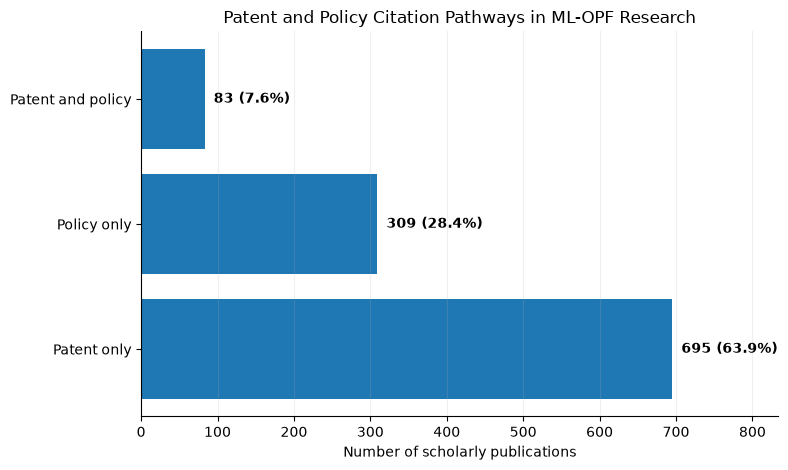

In [18]:
# ---------------------------------------------------------
# Patent-policy external citation pathways
# ---------------------------------------------------------

pathway_plot = (
    citation_pathway_overlap
    .copy()
)


pathway_plot[
    "Percent_of_external_cited"
] = (
    pathway_plot[
        "Percent_of_external_cited"
    ]
    .astype(float)
)


fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)


bars = ax.barh(
    pathway_plot[
        "Pathway"
    ],
    pathway_plot[
        "Documents"
    ],
)


for bar, (_, row) in zip(
    bars,
    pathway_plot.iterrows(),
):

    ax.text(
        bar.get_width() + 12,
        bar.get_y()
        + bar.get_height() / 2,
        (
            f"{int(row['Documents']):,} "
            f"({row['Percent_of_external_cited']:.1f}%)"
        ),
        va="center",
        fontsize=10,
        fontweight="bold",
    )


ax.set_xlabel(
    "Number of scholarly publications"
)

ax.set_ylabel(
    ""
)

ax.set_title(
    "Patent and Policy Citation Pathways in ML-OPF Research"
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


ax.grid(
    axis="x",
    alpha=0.20,
)


ax.set_xlim(
    0,
    pathway_plot[
        "Documents"
    ].max() * 1.20,
)


fig.tight_layout()


overlap_figure = (
    FIGURE_DIR
    / "patent_policy_pathway_overlap.pdf"
)


fig.savefig(
    overlap_figure,
    bbox_inches="tight",
)


print(
    "Saved:",
    overlap_figure
)


plt.show()

PATENT-POLICY CITATION OVERLAP
Patent-cited total : 778
Policy-cited total : 392
Unique union       : 1,087
Patent-cited only  : 695 (63.9%)
Policy-cited only  : 309 (28.4%)
Shared             : 83 (7.6%)

Saved: M:\projects_latex\review_paper_2\output\patent_policy_citation_landscape\figures\patent_policy_citation_overlap.pdf


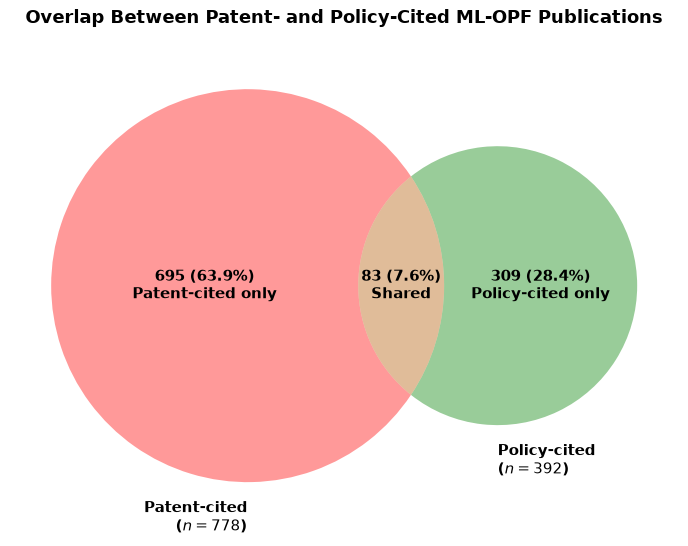

In [22]:
# ---------------------------------------------------------
# Venn diagram: patent- and policy-cited publications
# ---------------------------------------------------------

from matplotlib_venn import venn2
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Counts
# ---------------------------------------------------------

n_patent_only = len(
    patent_only_dois
)

n_policy_only = len(
    policy_only_dois
)

n_shared = len(
    shared_dois
)


n_patent_total = (
    n_patent_only
    + n_shared
)

n_policy_total = (
    n_policy_only
    + n_shared
)

n_union = (
    n_patent_only
    + n_policy_only
    + n_shared
)


# ---------------------------------------------------------
# Percentages of all unique externally cited publications
# ---------------------------------------------------------

patent_only_pct = (
    100
    * n_patent_only
    / n_union
)

policy_only_pct = (
    100
    * n_policy_only
    / n_union
)

shared_pct = (
    100
    * n_shared
    / n_union
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("PATENT-POLICY CITATION OVERLAP")
print("=" * 50)

print(
    "Patent-cited total :",
    f"{n_patent_total:,}"
)

print(
    "Policy-cited total :",
    f"{n_policy_total:,}"
)

print(
    "Unique union       :",
    f"{n_union:,}"
)

print(
    "Patent-cited only  :",
    f"{n_patent_only:,} ({patent_only_pct:.1f}%)"
)

print(
    "Policy-cited only  :",
    f"{n_policy_only:,} ({policy_only_pct:.1f}%)"
)

print(
    "Shared             :",
    f"{n_shared:,} ({shared_pct:.1f}%)"
)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.5, 5.5)
)


venn = venn2(
    subsets=(
        n_patent_only,
        n_policy_only,
        n_shared,
    ),
    set_labels=(
        f"Patent-cited\n($n={n_patent_total:,}$)",
        f"Policy-cited\n($n={n_policy_total:,}$)",
    ),
    ax=ax,
)


# ---------------------------------------------------------
# Region labels: count + percentage
# Percentage denominator = unique external-citation union
# ---------------------------------------------------------

region_labels = {
    "10": (
        f"{n_patent_only:,} "
        f"({patent_only_pct:.1f}%)\n"
        "Patent-cited only"
    ),

    "01": (
        f"{n_policy_only:,} "
        f"({policy_only_pct:.1f}%)\n"
        "Policy-cited only"
    ),

    "11": (
        f"{n_shared:,} "
        f"({shared_pct:.1f}%)\n"
        "Shared"
    ),
}


for region_id, region_text in region_labels.items():

    label = venn.get_label_by_id(
        region_id
    )

    if label is not None:

        label.set_text(
            region_text
        )

        label.set_fontsize(
            10.5
        )

        label.set_fontweight(
            "bold"
        )

        label.set_ha(
            "center"
        )

        label.set_va(
            "center"
        )


# ---------------------------------------------------------
# Set-label formatting
# ---------------------------------------------------------

for label in venn.set_labels:

    if label is not None:

        label.set_fontsize(
            11
        )

        label.set_fontweight(
            "bold"
        )


# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

ax.set_title(
    "Overlap Between Patent- and Policy-Cited ML-OPF Publications",
    fontsize=13,
    fontweight="bold",
    pad=18,
)


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

fig.tight_layout()


venn_figure = (
    FIGURE_DIR
    / "patent_policy_citation_overlap.pdf"
)


fig.savefig(
    venn_figure,
    format="pdf",
    bbox_inches="tight",
)


print()
print(
    "Saved:",
    venn_figure
)


plt.show()

In [23]:
# ---------------------------------------------------------
# Temporal evolution of external citations
# ---------------------------------------------------------

MAX_ANALYSIS_YEAR = 2026


patent_temporal = (
    patent_cited
    .loc[
        patent_cited[
            "Year_clean"
        ].le(
            MAX_ANALYSIS_YEAR
        )
    ]
    .groupby(
        "Year_clean"
    )
    .agg(
        Patent_Cited_Publications=(
            "DOI_clean",
            "nunique",
        ),
        Patent_Citations=(
            "Patent_Citation_Count",
            "sum",
        ),
        Mean_Patent_Citations=(
            "Patent_Citation_Count",
            "mean",
        ),
    )
    .reset_index()
    .rename(
        columns={
            "Year_clean":
                "Year"
        }
    )
)


policy_temporal = (
    policy_cited
    .loc[
        policy_cited[
            "Year_clean"
        ].le(
            MAX_ANALYSIS_YEAR
        )
    ]
    .groupby(
        "Year_clean"
    )
    .agg(
        Policy_Cited_Publications=(
            "DOI_clean",
            "nunique",
        ),
        Policy_Citations=(
            "Policy_Citation_Count",
            "sum",
        ),
        Mean_Policy_Citations=(
            "Policy_Citation_Count",
            "mean",
        ),
    )
    .reset_index()
    .rename(
        columns={
            "Year_clean":
                "Year"
        }
    )
)


external_temporal = (
    patent_temporal
    .merge(
        policy_temporal,
        on="Year",
        how="outer",
    )
    .sort_values(
        "Year"
    )
    .reset_index(
        drop=True
    )
)


display(
    external_temporal
)

,Year,Patent_Cited_Publications,Patent_Citations,Mean_Patent_Citations,Policy_Cited_Publications,Policy_Citations,Mean_Policy_Citations
0,1998,1,3,3.000000,1.0,1.0,1.000000
1,1999,1,4,4.000000,NaN,NaN,NaN
2,2000,3,5,1.666667,NaN,NaN,NaN
3,2001,2,9,4.500000,NaN,NaN,NaN
4,2002,3,10,3.333333,NaN,NaN,NaN
5,2003,1,1,1.000000,NaN,NaN,NaN
6,2004,4,10,2.500000,2.0,2.0,1.000000
7,2005,3,4,1.333333,1.0,1.0,1.000000
8,2006,1,2,2.000000,NaN,NaN,NaN
9,2007,2,2,1.000000,NaN,NaN,NaN


In [24]:
# ---------------------------------------------------------
# Most frequently patent-cited publications
# ---------------------------------------------------------

TOP_N_PUBLICATIONS = 10


top_patent_publications = (
    patent_cited[
        [
            "Title",
            "Authors",
            "Year",
            "Source title",
            "DOI",
            "Patent_Citation_Count",
            "Patent_Family_Count",
            "Cited by",
        ]
    ]
    .sort_values(
        [
            "Patent_Citation_Count",
            "Patent_Family_Count",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(
        TOP_N_PUBLICATIONS
    )
    .reset_index(
        drop=True
    )
)


top_patent_publications.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(top_patent_publications) + 1,
    ),
)


display(
    top_patent_publications
)

,Rank,Title,Authors,Year,Source title,DOI,Patent_Citation_Count,Patent_Family_Count,Cited by
0,1,A review on artificial intelligence based load...,Raza M.Q.; Khosravi A.,2015,Renewable and Sustainable Energy Reviews,10.1016/j.rser.2015.04.065,80,6,976
1,2,Artificial intelligence techniques for photovo...,Mellit A.; Kalogirou S.A.,2008,Progress in Energy and Combustion Science,10.1016/j.pecs.2008.01.001,19,10,923
2,3,Event-based energy optimum route planning in t...,Kladis G.P.; Economou J.T.; Knowles K.; Tsourd...,2014,"2009 European Control Conference, ECC 2009",10.23919/ecc.2009.7074582,18,14,0
3,4,A design of granular-oriented self-organizing ...,Oh S.-K.; Kim W.-D.; Park B.-J.; Pedrycz W.,2013,Neurocomputing,10.1016/j.neucom.2013.03.029,18,11,21
4,5,"Particle swarm optimization: Basic concepts, v...",del Valle Y.; Venayagamoorthy G.K.; Mohagheghi...,2008,IEEE Transactions on Evolutionary Computation,10.1109/TEVC.2007.896686,13,9,2157
5,6,Identification of power distribution network t...,Bolognani S.; Bof N.; Michelotti D.; Muraro R....,2013,Proceedings of the IEEE Conference on Decision...,10.1109/CDC.2013.6760120,11,8,212
6,7,Fully decentralized AC optimal power flow algo...,Sun A.X.; Phan D.T.; Ghosh S.,2013,IEEE Power and Energy Society General Meeting,10.1109/PESMG.2013.6672864,8,8,74
7,8,Model-Free Renewable Scenario Generation Using...,Chen Y.; Wang Y.; Kirschen D.; Zhang B.,2018,IEEE Transactions on Power Systems,10.1109/TPWRS.2018.2794541,8,5,721
8,9,Stability and convergence of distributed algor...,Devane E.; Lestas I.,2013,Proceedings of the IEEE Conference on Decision...,10.1109/CDC.2013.6760329,7,7,12
9,10,Distributed algorithm for optimal power flow o...,Peng Q.; Low S.H.,2014,Proceedings of the IEEE Conference on Decision...,10.1109/CDC.2014.7039376,7,7,83


In [25]:
# ---------------------------------------------------------
# Most frequently policy-cited publications
# ---------------------------------------------------------

top_policy_publications = (
    policy_cited[
        [
            "Title",
            "Authors",
            "Year",
            "Journal",
            "DOI",
            "Policy_Citation_Count",
            "Cited by",
        ]
    ]
    .sort_values(
        "Policy_Citation_Count",
        ascending=False,
    )
    .head(
        TOP_N_PUBLICATIONS
    )
    .reset_index(
        drop=True
    )
)


top_policy_publications.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(top_policy_publications) + 1,
    ),
)


display(
    top_policy_publications
)

,Rank,Title,Authors,Year,Journal,DOI,Policy_Citation_Count,Cited by
0,1,Tackling Climate Change with Machine Learning,David Rolnick - McGill University; David Rolni...,2023,ACM Computing Surveys,10.1145/3485128,59,867
1,2,The Future of Electric Power in the United States,NaN,2021,Unknown,10.17226/25968,29,26
2,3,The AI gambit: leveraging artificial intellige...,Josh Cowls - University of Oxford; Andreas Tsa...,2023,AI & SOCIETY,10.1007/s00146-021-01294-x,29,370
3,4,A review on artificial intelligence based load...,Muhammad Qamar Raza - The University of Queens...,2015,Renewable and Sustainable Energy Reviews,10.1016/j.rser.2015.04.065,21,976
4,5,Peer-to-peer and community-based markets: A co...,Tiago Sousa - Technical University of Denmark;...,2019,Renewable and Sustainable Energy Reviews,10.1016/j.rser.2019.01.036,20,892
5,6,PyPSA-Eur: An open optimisation model of the E...,Jonas Hörsch - Frankfurt Institute for Advance...,2018,Energy Strategy Reviews,10.1016/j.esr.2018.08.012,16,344
6,7,Beyond the State of the Art of Electric Vehicl...,Joeri Van Mierlo - Vrije Universiteit Brussel;...,2021,World Electric Vehicle Journal,10.3390/wevj12010020,15,131
7,8,Forecasting: theory and practice,Fotios Petropoulos - University of Bath; Danie...,2022,International Journal of Forecasting,10.1016/j.ijforecast.2021.11.001,14,794
8,9,Hybrid-augmented intelligence: collaboration a...,Nanning Zheng - Xi'an Jiaotong University; Ziy...,2017,Frontiers of Information Technology & Electron...,10.1631/fitee.1700053,9,402
9,10,A Survey on Power System Blackout and Cascadin...,Hassan Haes Alhelou - Isfahan University of Te...,2019,Energies,10.3390/en12040682,9,591


In [26]:
# ---------------------------------------------------------
# Journal representation across external-citation pathways
# ---------------------------------------------------------

patent_journals = (
    patent_cited
    .groupby(
        "Source title"
    )
    .agg(
        Patent_Publications=(
            "DOI_clean",
            "nunique",
        ),
        Patent_Citations=(
            "Patent_Citation_Count",
            "sum",
        ),
    )
    .reset_index()
    .rename(
        columns={
            "Source title":
                "Journal"
        }
    )
)


policy_journals = (
    policy_cited
    .groupby(
        "Journal"
    )
    .agg(
        Policy_Publications=(
            "DOI_clean",
            "nunique",
        ),
        Policy_Citations=(
            "Policy_Citation_Count",
            "sum",
        ),
    )
    .reset_index()
)


journal_comparison = (
    patent_journals
    .merge(
        policy_journals,
        on="Journal",
        how="outer",
    )
    .fillna(
        0
    )
)


journal_comparison[
    "Total_External_Publications"
] = (
    journal_comparison[
        "Patent_Publications"
    ]
    +
    journal_comparison[
        "Policy_Publications"
    ]
)


journal_comparison = (
    journal_comparison
    .sort_values(
        "Total_External_Publications",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


display(
    journal_comparison.head(20)
)

,Journal,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations,Total_External_Publications
0,IEEE Access,66.0,107.0,19.0,25.0,85.0
1,IEEE Transactions on Power Systems,61.0,115.0,22.0,38.0,83.0
2,IEEE Transactions on Smart Grid,58.0,86.0,20.0,30.0,78.0
3,Applied Energy,35.0,51.0,23.0,37.0,58.0
4,Energies,31.0,37.0,17.0,43.0,48.0
5,Renewable and Sustainable Energy Reviews,14.0,109.0,28.0,90.0,42.0
6,Electric Power Systems Research,13.0,21.0,12.0,17.0,25.0
7,International Journal of Electrical Power and ...,19.0,24.0,0.0,0.0,19.0
8,IEEE Transactions on Sustainable Energy,14.0,20.0,4.0,4.0,18.0
9,Proceedings of the IEEE,10.0,22.0,6.0,17.0,16.0


Saved: M:\projects_latex\review_paper_2\output\patent_policy_citation_landscape\figures\patent_policy_temporal_evolution.pdf


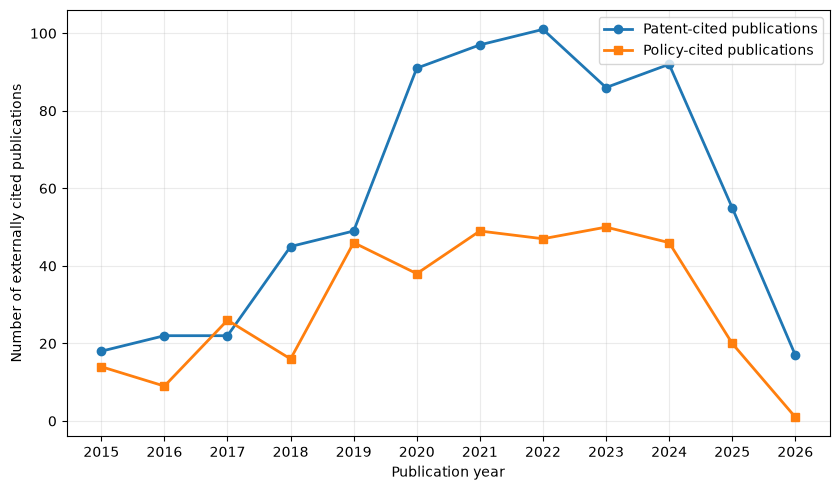

In [27]:
# ---------------------------------------------------------
# Temporal evolution of patent- and policy-cited publications
# ---------------------------------------------------------

TEMPORAL_START_YEAR = 2015
TEMPORAL_END_YEAR = 2026


temporal_plot = (
    external_temporal
    .loc[
        lambda df:
            df["Year"].between(
                TEMPORAL_START_YEAR,
                TEMPORAL_END_YEAR,
            )
    ]
    .copy()
)


# Years without observations represent zero cited publications.
for column in [
    "Patent_Cited_Publications",
    "Policy_Cited_Publications",
]:

    temporal_plot[
        column
    ] = (
        temporal_plot[
            column
        ]
        .fillna(0)
    )


fig, ax = plt.subplots(
    figsize=(8.5, 5.0)
)


ax.plot(
    temporal_plot["Year"],
    temporal_plot["Patent_Cited_Publications"],
    marker="o",
    linewidth=2,
    label="Patent-cited publications",
)


ax.plot(
    temporal_plot["Year"],
    temporal_plot["Policy_Cited_Publications"],
    marker="s",
    linewidth=2,
    label="Policy-cited publications",
)


ax.set_xlabel(
    "Publication year"
)

ax.set_ylabel(
    "Number of externally cited publications"
)


ax.set_xticks(
    temporal_plot["Year"]
)


ax.legend(
    frameon=True
)


ax.grid(
    alpha=0.25
)


fig.tight_layout()


temporal_figure = (
    FIGURE_DIR
    / "patent_policy_temporal_evolution.pdf"
)


fig.savefig(
    temporal_figure,
    format="pdf",
    bbox_inches="tight",
)


print(
    "Saved:",
    temporal_figure
)


plt.show()

In [55]:
# ---------------------------------------------------------
# Compact top patent-cited table
# ---------------------------------------------------------

top_patent_table = (
    top_patent_publications[
        [
            "Rank",
            "Title",
            "Year",
            "Source title",
            "Patent_Citation_Count",
            "Patent_Family_Count",
        ]
    ]
    .copy()
    .rename(
        columns={
            "Source title":
                "Journal",

            "Patent_Citation_Count":
                "Patent citations",

            "Patent_Family_Count":
                "Citing patent families",
        }
    )
)


display(
    top_patent_table
)

# ---------------------------------------------------------
# Save top patent-cited publications
# ---------------------------------------------------------

top_patent_table_file = (
    TABLE_DIR
    / "top_patent_cited_publications.csv"
)


top_patent_table.to_csv(
    top_patent_table_file,
    index=False,
)


print(
    "Saved:",
    top_patent_table_file
)

,Rank,Title,Year,Journal,Patent citations,Citing patent families
0,1,A review on artificial intelligence based load...,2015,Renewable and Sustainable Energy Reviews,80,6
1,2,Artificial intelligence techniques for photovo...,2008,Progress in Energy and Combustion Science,19,10
2,3,Event-based energy optimum route planning in t...,2014,"2009 European Control Conference, ECC 2009",18,14
3,4,A design of granular-oriented self-organizing ...,2013,Neurocomputing,18,11
4,5,"Particle swarm optimization: Basic concepts, v...",2008,IEEE Transactions on Evolutionary Computation,13,9
5,6,Identification of power distribution network t...,2013,Proceedings of the IEEE Conference on Decision...,11,8
6,7,Fully decentralized AC optimal power flow algo...,2013,IEEE Power and Energy Society General Meeting,8,8
7,8,Model-Free Renewable Scenario Generation Using...,2018,IEEE Transactions on Power Systems,8,5
8,9,Stability and convergence of distributed algor...,2013,Proceedings of the IEEE Conference on Decision...,7,7
9,10,Distributed algorithm for optimal power flow o...,2014,Proceedings of the IEEE Conference on Decision...,7,7


Saved: M:\projects_latex\review_paper_2\output\patent_policy_citation_landscape\tables\top_patent_cited_publications.csv


In [56]:
# ---------------------------------------------------------
# Compact top policy-cited table
# ---------------------------------------------------------

top_policy_table = (
    top_policy_publications[
        [
            "Rank",
            "Title",
            "Year",
            "Journal",
            "Policy_Citation_Count",
        ]
    ]
    .copy()
    .rename(
        columns={
            "Policy_Citation_Count":
                "Policy citations",
        }
    )
)


display(
    top_policy_table
)

# ---------------------------------------------------------
# Save top policy-cited publications
# ---------------------------------------------------------

top_policy_table_file = (
    TABLE_DIR
    / "top_policy_cited_publications.csv"
)


top_policy_table.to_csv(
    top_policy_table_file,
    index=False,
)


print(
    "Saved:",
    top_policy_table_file
)

,Rank,Title,Year,Journal,Policy citations
0,1,Tackling Climate Change with Machine Learning,2023,ACM Computing Surveys,59
1,2,The Future of Electric Power in the United States,2021,Unknown,29
2,3,The AI gambit: leveraging artificial intellige...,2023,AI & SOCIETY,29
3,4,A review on artificial intelligence based load...,2015,Renewable and Sustainable Energy Reviews,21
4,5,Peer-to-peer and community-based markets: A co...,2019,Renewable and Sustainable Energy Reviews,20
5,6,PyPSA-Eur: An open optimisation model of the E...,2018,Energy Strategy Reviews,16
6,7,Beyond the State of the Art of Electric Vehicl...,2021,World Electric Vehicle Journal,15
7,8,Forecasting: theory and practice,2022,International Journal of Forecasting,14
8,9,Hybrid-augmented intelligence: collaboration a...,2017,Frontiers of Information Technology & Electron...,9
9,10,A Survey on Power System Blackout and Cascadin...,2019,Energies,9


Saved: M:\projects_latex\review_paper_2\output\patent_policy_citation_landscape\tables\top_policy_cited_publications.csv


In [30]:
# ---------------------------------------------------------
# Comparative journal representation
# ---------------------------------------------------------

journal_comparison[
    "Patent_Publications"
] = (
    journal_comparison[
        "Patent_Publications"
    ]
    .astype(int)
)

journal_comparison[
    "Policy_Publications"
] = (
    journal_comparison[
        "Policy_Publications"
    ]
    .astype(int)
)

journal_comparison[
    "Patent_Citations"
] = (
    journal_comparison[
        "Patent_Citations"
    ]
    .astype(int)
)

journal_comparison[
    "Policy_Citations"
] = (
    journal_comparison[
        "Policy_Citations"
    ]
    .astype(int)
)


journal_comparison[
    "Patent_Rank"
] = (
    journal_comparison[
        "Patent_Publications"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)


journal_comparison[
    "Policy_Rank"
] = (
    journal_comparison[
        "Policy_Publications"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)


journal_comparison = (
    journal_comparison
    .sort_values(
        [
            "Patent_Publications",
            "Policy_Publications",
        ],
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


display(
    journal_comparison.head(20)
)

,Journal,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations,Total_External_Publications,Patent_Rank,Policy_Rank
0,IEEE Access,66,107,19,25,85.0,1,5
1,IEEE Transactions on Power Systems,61,115,22,38,83.0,2,3
2,IEEE Transactions on Smart Grid,58,86,20,30,78.0,3,4
3,Applied Energy,35,51,23,37,58.0,4,2
4,Energies,31,37,17,43,48.0,5,6
5,International Journal of Electrical Power and ...,19,24,0,0,19.0,6,175
6,Renewable and Sustainable Energy Reviews,14,109,28,90,42.0,7,1
7,IEEE Transactions on Sustainable Energy,14,20,4,4,18.0,7,16
8,Electric Power Systems Research,13,21,12,17,25.0,9,7
9,Journal of Modern Power Systems and Clean Energy,12,17,1,2,13.0,10,45


In [37]:
# ---------------------------------------------------------
# Parse individual Scopus authors
# ---------------------------------------------------------

def parse_scopus_authors(value):

    if pd.isna(value):
        return []

    return [
        author.strip()
        for author in str(value).split(";")
        if author.strip()
    ]

# ---------------------------------------------------------
# Patent-cited authors
# ---------------------------------------------------------

patent_author_data = (
    patent_cited[
        [
            "DOI_clean",
            "Author full names",
            "Patent_Citation_Count",
        ]
    ]
    .copy()
)


patent_author_data[
    "Author"
] = (
    patent_author_data[
        "Author full names"
    ]
    .apply(
        parse_scopus_authors
    )
)


patent_author_data = (
    patent_author_data
    .explode(
        "Author"
    )
    .dropna(
        subset=[
            "Author"
        ]
    )
)    

# ---------------------------------------------------------
# Policy-cited authors
# ---------------------------------------------------------

policy_author_data = (
    policy_cited[
        [
            "DOI_clean",
            "Author full names",
            "Policy_Citation_Count",
        ]
    ]
    .copy()
)


policy_author_data[
    "Author"
] = (
    policy_author_data[
        "Author full names"
    ]
    .apply(
        parse_scopus_authors
    )
)


policy_author_data = (
    policy_author_data
    .explode(
        "Author"
    )
    .dropna(
        subset=[
            "Author"
        ]
    )
)

# ---------------------------------------------------------
# Author-level external citation representation
# ---------------------------------------------------------

patent_authors = (
    patent_author_data
    .groupby(
        "Author"
    )
    .agg(
        Patent_Publications=(
            "DOI_clean",
            "nunique",
        ),
        Patent_Citations=(
            "Patent_Citation_Count",
            "sum",
        ),
    )
    .reset_index()
)


policy_authors = (
    policy_author_data
    .groupby(
        "Author"
    )
    .agg(
        Policy_Publications=(
            "DOI_clean",
            "nunique",
        ),
        Policy_Citations=(
            "Policy_Citation_Count",
            "sum",
        ),
    )
    .reset_index()
)


author_comparison = (
    patent_authors
    .merge(
        policy_authors,
        on="Author",
        how="outer",
    )
    .fillna(0)
)


for column in [
    "Patent_Publications",
    "Patent_Citations",
    "Policy_Publications",
    "Policy_Citations",
]:

    author_comparison[
        column
    ] = (
        author_comparison[
            column
        ]
        .astype(int)
    )


display(
    author_comparison
    .sort_values(
        "Patent_Publications",
        ascending=False,
    )
    .head(20)
)

display(
    author_comparison
    .sort_values(
        "Policy_Publications",
        ascending=False,
    )
    .head(20)
)

,Author,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations
2946,"Shahidehpour, Mohammad (6603715241)",10,13,1,1
1088,"Giannakis, Georgios B. (36049280600)",8,18,2,3
3627,"Wu, Wenchuan (56195909500)",8,12,1,2
776,"Diao, Ruisheng (26649396700)",7,15,0,0
366,"Blaabjerg, Frede (7004992352)",7,9,1,1
2299,"Mirjalili, Seyedali (51461922300)",7,9,1,1
1958,"Lin, Chenhui (57191524053)",6,7,0,0
3616,"Wu, Lei (55806506700)",6,9,2,2
3124,"Sun, Hongbin (7404827571)",6,11,2,3
3427,"Wang, Jianhui (57200038380)",6,9,3,4


,Author,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations
336,"Bernstein, Andrey (57211574330)",1,4,6,11
4048,"Zhang, Yingchen (56021347300)",1,1,6,10
2638,"Pinson, Pierre (19337428700)",1,1,5,42
1516,"Jiang, Huaiguang (55651842000)",2,2,5,7
331,"Berg, Kjersti (57205420150)",0,0,4,5
712,"Dall'Anese, Emiliano (35078261000)",2,6,4,7
1673,"King, Jennifer (57210564217)",0,0,4,4
1325,"Hodge, Bri-Mathias (35757689400)",0,0,4,12
1645,"Khodaei, Amin (23008649300)",0,0,4,5
1235,"Hannan, M.A. (7103014445)",3,8,3,3


In [38]:
# ---------------------------------------------------------
# Country normalization dictionary
# ---------------------------------------------------------

COUNTRY_ALIASES = {

    "United States": "United States",
    "USA": "United States",

    "United Kingdom": "United Kingdom",
    "UK": "United Kingdom",

    "China": "China",
    "Australia": "Australia",
    "Malaysia": "Malaysia",
    "Algeria": "Algeria",
    "Cyprus": "Cyprus",
    "South Korea": "South Korea",
    "Korea": "South Korea",
    "Canada": "Canada",
    "Poland": "Poland",
    "Italy": "Italy",

    "Netherlands": "Netherlands",
    "Belgium": "Belgium",
    "Germany": "Germany",

    "India": "India",
    "Pakistan": "Pakistan",
    "Iraq": "Iraq",
    "Uzbekistan": "Uzbekistan",
    "South Africa": "South Africa",
    "Jordan": "Jordan",
    "Ukraine": "Ukraine",

    "Saudi Arabia": "Saudi Arabia",
    "France": "France",
    "Spain": "Spain",
    "Portugal": "Portugal",
    "Sweden": "Sweden",
    "Norway": "Norway",
    "Denmark": "Denmark",
    "Finland": "Finland",
    "Switzerland": "Switzerland",
    "Austria": "Austria",
    "Greece": "Greece",
    "Turkey": "Turkey",
    "Türkiye": "Turkey",

    "Japan": "Japan",
    "Singapore": "Singapore",
    "Taiwan": "Taiwan",
    "Hong Kong": "Hong Kong",

    "Brazil": "Brazil",
    "Mexico": "Mexico",
    "Chile": "Chile",
    "Argentina": "Argentina",

    "Iran": "Iran",
    "United Arab Emirates": "United Arab Emirates",
    "Qatar": "Qatar",
    "Egypt": "Egypt",
}

In [39]:
# ---------------------------------------------------------
# Extract countries from affiliation strings
# ---------------------------------------------------------

def extract_countries(value):

    if pd.isna(value):
        return []

    text = str(value)

    countries = set()

    for alias, canonical in COUNTRY_ALIASES.items():

        if alias.lower() in text.lower():

            countries.add(
                canonical
            )

    return sorted(
        countries
    )

In [43]:
# ---------------------------------------------------------
# Patent-cited country representation
# ---------------------------------------------------------

patent_country_data = (
    patent_cited[
        [
            "DOI_clean",
            "Affiliations",
            "Patent_Citation_Count",
        ]
    ]
    .copy()
)


patent_country_data[
    "Country"
] = (
    patent_country_data[
        "Affiliations"
    ]
    .apply(
        extract_countries
    )
)


patent_country_data = (
    patent_country_data
    .explode(
        "Country"
    )
    .dropna(
        subset=[
            "Country"
        ]
    )
)

In [44]:
# ---------------------------------------------------------
# Policy-cited country representation
# ---------------------------------------------------------

policy_country_data = (
    policy_cited[
        [
            "DOI_clean",
            "Affiliations",
            "Policy_Citation_Count",
        ]
    ]
    .copy()
)


policy_country_data[
    "Country"
] = (
    policy_country_data[
        "Affiliations"
    ]
    .apply(
        extract_countries
    )
)


policy_country_data = (
    policy_country_data
    .explode(
        "Country"
    )
    .dropna(
        subset=[
            "Country"
        ]
    )
)

In [45]:
patent_countries = (
    patent_country_data
    .groupby(
        "Country"
    )
    .agg(
        Patent_Publications=(
            "DOI_clean",
            "nunique",
        ),
        Patent_Citations=(
            "Patent_Citation_Count",
            "sum",
        ),
    )
    .reset_index()
)


policy_countries = (
    policy_country_data
    .groupby(
        "Country"
    )
    .agg(
        Policy_Publications=(
            "DOI_clean",
            "nunique",
        ),
        Policy_Citations=(
            "Policy_Citation_Count",
            "sum",
        ),
    )
    .reset_index()
)


country_comparison = (
    patent_countries
    .merge(
        policy_countries,
        on="Country",
        how="outer",
    )
    .fillna(0)
)


for column in [
    "Patent_Publications",
    "Patent_Citations",
    "Policy_Publications",
    "Policy_Citations",
]:

    country_comparison[
        column
    ] = (
        country_comparison[
            column
        ]
        .astype(int)
    )


display(
    country_comparison
    .sort_values(
        "Patent_Publications",
        ascending=False,
    )
    .head(20)
)

,Country,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations
7,China,326,409,51,103
42,United States,228,449,150,335
41,United Kingdom,60,105,33,100
16,India,52,86,30,37
1,Australia,40,141,20,60
5,Canada,34,71,15,26
17,Iran,28,31,16,32
19,Italy,24,49,20,54
33,South Korea,23,51,11,35
30,Saudi Arabia,22,37,12,19


In [46]:
display(
    country_comparison
    .sort_values(
        "Policy_Publications",
        ascending=False,
    )
    .head(20)
)

,Country,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations
42,United States,228,449,150,335
7,China,326,409,51,103
41,United Kingdom,60,105,33,100
16,India,52,86,30,37
13,Germany,19,25,27,75
9,Denmark,20,26,22,74
1,Australia,40,141,20,60
19,Italy,24,49,20,54
36,Switzerland,13,28,17,51
25,Norway,6,12,16,39


In [47]:
# ---------------------------------------------------------
# Leading authors in the patent-citation pathway
# ---------------------------------------------------------

top_patent_authors = (
    author_comparison
    .sort_values(
        [
            "Patent_Publications",
            "Patent_Citations",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(10)
    .reset_index(drop=True)
)


top_patent_authors.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(top_patent_authors) + 1,
    ),
)


display(
    top_patent_authors
)

,Rank,Author,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations
0,1,"Shahidehpour, Mohammad (6603715241)",10,13,1,1
1,2,"Giannakis, Georgios B. (36049280600)",8,18,2,3
2,3,"Wu, Wenchuan (56195909500)",8,12,1,2
3,4,"Diao, Ruisheng (26649396700)",7,15,0,0
4,5,"Blaabjerg, Frede (7004992352)",7,9,1,1
5,6,"Mirjalili, Seyedali (51461922300)",7,9,1,1
6,7,"Sun, Hongbin (7404827571)",6,11,2,3
7,8,"Wang, Jianhui (57200038380)",6,9,3,4
8,9,"Wu, Lei (55806506700)",6,9,2,2
9,10,"Lin, Chenhui (57191524053)",6,7,0,0


In [48]:
# ---------------------------------------------------------
# Leading authors in the policy-citation pathway
# ---------------------------------------------------------

top_policy_authors = (
    author_comparison
    .sort_values(
        [
            "Policy_Publications",
            "Policy_Citations",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(10)
    .reset_index(drop=True)
)


top_policy_authors.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(top_policy_authors) + 1,
    ),
)


display(
    top_policy_authors
)

,Rank,Author,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations
0,1,"Bernstein, Andrey (57211574330)",1,4,6,11
1,2,"Zhang, Yingchen (56021347300)",1,1,6,10
2,3,"Pinson, Pierre (19337428700)",1,1,5,42
3,4,"Jiang, Huaiguang (55651842000)",2,2,5,7
4,5,"Hodge, Bri-Mathias (35757689400)",0,0,4,12
5,6,"Dall'Anese, Emiliano (35078261000)",2,6,4,7
6,7,"Berg, Kjersti (57205420150)",0,0,4,5
7,8,"Khodaei, Amin (23008649300)",0,0,4,5
8,9,"King, Jennifer (57210564217)",0,0,4,4
9,10,"Molzahn, Daniel K. (36444969800)",1,2,3,12


In [49]:
# ---------------------------------------------------------
# Top journals by pathway
# ---------------------------------------------------------

top_patent_journals = (
    journal_comparison
    .sort_values(
        [
            "Patent_Publications",
            "Patent_Citations",
        ],
        ascending=False,
    )
    .head(5)
    [
        [
            "Journal",
            "Patent_Publications",
            "Patent_Citations",
        ]
    ]
    .reset_index(drop=True)
)


top_policy_journals = (
    journal_comparison
    .sort_values(
        [
            "Policy_Publications",
            "Policy_Citations",
        ],
        ascending=False,
    )
    .head(5)
    [
        [
            "Journal",
            "Policy_Publications",
            "Policy_Citations",
        ]
    ]
    .reset_index(drop=True)
)


display(top_patent_journals)
display(top_policy_journals)

,Journal,Patent_Publications,Patent_Citations
0,IEEE Access,66,107
1,IEEE Transactions on Power Systems,61,115
2,IEEE Transactions on Smart Grid,58,86
3,Applied Energy,35,51
4,Energies,31,37


,Journal,Policy_Publications,Policy_Citations
0,Renewable and Sustainable Energy Reviews,28,90
1,Applied Energy,23,37
2,IEEE Transactions on Power Systems,22,38
3,IEEE Transactions on Smart Grid,20,30
4,IEEE Access,19,25


In [50]:
# ---------------------------------------------------------
# Top countries by pathway
# ---------------------------------------------------------

top_patent_countries = (
    country_comparison
    .sort_values(
        [
            "Patent_Publications",
            "Patent_Citations",
        ],
        ascending=False,
    )
    .head(5)
    [
        [
            "Country",
            "Patent_Publications",
            "Patent_Citations",
        ]
    ]
    .reset_index(drop=True)
)


top_policy_countries = (
    country_comparison
    .sort_values(
        [
            "Policy_Publications",
            "Policy_Citations",
        ],
        ascending=False,
    )
    .head(5)
    [
        [
            "Country",
            "Policy_Publications",
            "Policy_Citations",
        ]
    ]
    .reset_index(drop=True)
)


display(top_patent_countries)
display(top_policy_countries)

,Country,Patent_Publications,Patent_Citations
0,China,326,409
1,United States,228,449
2,United Kingdom,60,105
3,India,52,86
4,Australia,40,141


,Country,Policy_Publications,Policy_Citations
0,United States,150,335
1,China,51,103
2,United Kingdom,33,100
3,India,30,37
4,Germany,27,75


In [51]:
# ---------------------------------------------------------
# Country pathway specialization
# ---------------------------------------------------------

EPSILON = 0.5

N_PATENT = len(
    patent_cited
)

N_POLICY = len(
    policy_cited
)


country_comparison[
    "Patent_Share"
] = (
    country_comparison[
        "Patent_Publications"
    ]
    /
    N_PATENT
)


country_comparison[
    "Policy_Share"
] = (
    country_comparison[
        "Policy_Publications"
    ]
    /
    N_POLICY
)


country_comparison[
    "Pathway_Specialization"
] = np.log2(
    (
        country_comparison[
            "Patent_Publications"
        ]
        + EPSILON
    )
    /
    (
        N_PATENT
        + EPSILON
    )
    /
    (
        (
            country_comparison[
                "Policy_Publications"
            ]
            + EPSILON
        )
        /
        (
            N_POLICY
            + EPSILON
        )
    )
)


display(
    country_comparison
    .sort_values(
        "Pathway_Specialization",
        ascending=False,
    )
    [
        [
            "Country",
            "Patent_Publications",
            "Policy_Publications",
            "Pathway_Specialization",
        ]
    ]
    .head(15)
)

,Country,Patent_Publications,Policy_Publications,Pathway_Specialization
20,Japan,8,0,3.099458
7,China,326,51,1.676434
31,Singapore,17,4,0.971354
0,Algeria,4,1,0.596958
38,Turkey,12,4,0.485927
10,Egypt,14,5,0.410545
15,Hong Kong,19,7,0.390507
2,Austria,3,1,0.234388
5,Canada,34,15,0.166324
6,Chile,5,2,0.149499


In [52]:
# ---------------------------------------------------------
# Top authors by patent-cited publications
# ---------------------------------------------------------

top_patent_authors = (
    author_comparison
    .sort_values(
        [
            "Patent_Publications",
            "Patent_Citations",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(5)
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Top authors by policy-cited publications
# ---------------------------------------------------------

top_policy_authors = (
    author_comparison
    .sort_values(
        [
            "Policy_Publications",
            "Policy_Citations",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(5)
    .reset_index(drop=True)
)


display(
    top_patent_authors
)

display(
    top_policy_authors
)

,Author,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations
0,"Shahidehpour, Mohammad (6603715241)",10,13,1,1
1,"Giannakis, Georgios B. (36049280600)",8,18,2,3
2,"Wu, Wenchuan (56195909500)",8,12,1,2
3,"Diao, Ruisheng (26649396700)",7,15,0,0
4,"Blaabjerg, Frede (7004992352)",7,9,1,1


,Author,Patent_Publications,Patent_Citations,Policy_Publications,Policy_Citations
0,"Bernstein, Andrey (57211574330)",1,4,6,11
1,"Zhang, Yingchen (56021347300)",1,1,6,10
2,"Pinson, Pierre (19337428700)",1,1,5,42
3,"Jiang, Huaiguang (55651842000)",2,2,5,7
4,"Hodge, Bri-Mathias (35757689400)",0,0,4,12


In [53]:
# ---------------------------------------------------------
# Comparative leading-journal table
# ---------------------------------------------------------

TOP_N = 5


leading_journals_table = pd.DataFrame(
    {
        "Rank": np.arange(
            1,
            TOP_N + 1,
        ),

        "Patent_Journal": (
            top_patent_journals[
                "Journal"
            ]
            .head(TOP_N)
            .values
        ),

        "Patent_Publications": (
            top_patent_journals[
                "Patent_Publications"
            ]
            .head(TOP_N)
            .values
        ),

        "Patent_Citations": (
            top_patent_journals[
                "Patent_Citations"
            ]
            .head(TOP_N)
            .values
        ),

        "Policy_Journal": (
            top_policy_journals[
                "Journal"
            ]
            .head(TOP_N)
            .values
        ),

        "Policy_Publications": (
            top_policy_journals[
                "Policy_Publications"
            ]
            .head(TOP_N)
            .values
        ),

        "Policy_Citations": (
            top_policy_journals[
                "Policy_Citations"
            ]
            .head(TOP_N)
            .values
        ),
    }
)


display(
    leading_journals_table
)

,Rank,Patent_Journal,Patent_Publications,Patent_Citations,Policy_Journal,Policy_Publications,Policy_Citations
0,1,IEEE Access,66,107,Renewable and Sustainable Energy Reviews,28,90
1,2,IEEE Transactions on Power Systems,61,115,Applied Energy,23,37
2,3,IEEE Transactions on Smart Grid,58,86,IEEE Transactions on Power Systems,22,38
3,4,Applied Energy,35,51,IEEE Transactions on Smart Grid,20,30
4,5,Energies,31,37,IEEE Access,19,25
